<a href="https://colab.research.google.com/github/bidallei/MIAAD-UACJ/blob/main/ProyectoProgADAP_263150.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Proyecto de Programación para Analítica Descriptiva y Predictiva**
## Nombre del Proyecto: Hongos del estado de Veracruz
## Autor: Álvaro Hernández Jarquín
## Matrícula: 263150
## Fecha: 10 de octubre de 2025

# **1. Introducción**

#Descripción del problema: ¿Qué queremos analizar o predecir?
Queremos analizar la diversidad y modelar la distribución geográfica de los hongos en el estado de Veracruz, México. El objetivo principal es realizar un modelo de distribución de especies (SDM, por sus siglas en inglés: _Species Distribution Models_) que, a partir de coordenadas geográficas (latitud, longitud y altitud) prediga la probabilidad de presencia de especies de hongos en distintas zonas del estado.

"Los modelos de distribución de especies (SDMs) que relacionan información sobre la presencia/ausencia o abundancia de una especie con variables ambientales para predecir dónde ( y en qué medida) es probable que esté presente una especie en ubicaciones o periodos de tiempo no muestreados, son herramientas importantes en muchos campos aplicados"(Martínez-Minaya, et. al.,
2018)

#Objetivo del análisis: ¿Qué impacto tendrá este análisis?
Este análisis servirá como una herramienta fundamental para  identificar las  áreas con mayor probabilidad de ocurrencia de especies de hongos, teniendo así una herramienta de apoyo para la investigación micológica, la conservación de la biodiversidad y la planificación ambiental.


#Estudios previos o soluciones similares a esta problemática

* Araújo, M. B., & Peterson, A. T. (2012). Uses and misuses of bioclimatic envelope modeling. Ecology, 93(7), 1527–1539. https://doi.org/10.1111/j.1365-2745.2012.02000.x

* Guillera-Arroita, G., Lahoz-Monfort, J. J., Elith, J., Gordon, A., Kujala, H., Lentini, P. E., McCarthy, M. A., Tingley, R., & Wintle, B. A. (2015). Is my species distribution model fit for purpose? Matching data and models to applications. Global Ecology and Biogeography, 24(3), 276–292. https://doi.org/10.1111/geb.12268

* Martínez-Minaya, J., Cameletti, M., Conesa, D., & Pennino, M. G. (2018). Species distribution modeling: A statistical review with focus in spatio-temporal issues. Stochastic Environmental Research and Risk Assessment, 32(11), 3227–3244. https://link.springer.com/article/10.1007/s00477-018-1548-7

* Norberg, A., Abrego, N., Blanchet, F. G., Adler, F. R., Anderson, B. J., Anttila, J., Araújo, M. B., Dallas, T., Dunson, D., Elith, J., Foster, S. D., Fox, R., Franklin, J., Godsoe, W., Guisan, A., O'Hara, B., Hill, N. A., Holt, R. D., Hui, F. K. C., … Ovaskainen, O. (2019). A comprehensive evaluation of predictive performance of 33 species distribution models at species and community levels. Ecological Monographs, 89(3), e01370. https://doi.org/10.1002/ecm.1370



##Fuente de datos: ¿De dónde provienen los datos?
**Fuente/Repositorio:** GBIF (Global Biodiversity Information Facility)<br>
**URL del Conjunto de Datos:** https://www.gbif.org/dataset/7f790c86-f762-11e1-a439-00145eb45e9a<br>
**Publicado por:** Comisión nacional para el conocimiento y uso de la biodiversidad (CONABIO)<br>
**Título del Dataset:** Hongos del estado de Veracruz, México<br>
**Descripción:** El dataset contiene registros de especímenes de hongos depositados principalmente en el Herbario XAL (INECOL), con adiciones de los herbarios ENCB, NY y la Universidad de Guadalajara. Todos los ejemplares son procedentes del estado de Veracruz.


# **2. Captura y Carga de Datos**

##Explicación de la fuente de datos: ¿Cuáles son las fuentes de datos?, ¿Qué formato tienen los datos (CSV, SQL, API, etc.)?, ¿Cuántas observaciones y variables contiene el dataset?
* Fuente: El dataset se descarga directamente desde el portal de GBIF en formato comprimido ZIP. Al descomprimirlo, se obtiene un archivo en formato CSV.

* Observaciones y Variables: El dataset original contiene 6,149 registros (filas) y 50 campos (columnas) con información sobre cada espécimen, como taxonomía, ubicación, fecha de recolección, colector e identificador.

##Explicación sobre problemas en la carga de Datos y el Código para la carga de datos desde archivos (bibiotecas, etc.)
El principal problema potencial es la gestión de la memoria al cargar un archivo CSV grande. Para ello, se utilizan bibliotecas como pandas.

#**3.Transformación y Preprocesamiento - Data Wrangling**

##Explicación sobre cada una de las problemáticas encontradas, las soluciones y el código
Al abrir la base de datos en excel, fue claro que las columnas no estaban divididas en comas, por lo que se realizó la separación por espacios, pero no funcionó. Así que al abrir el archivo en un editor de texto pude constatar que la división era en tabuladores, por lo que se debe usar `sep="\t"`
##Identificación de Tipos de Datos
Al imprimir la información de la base de datos observamos
- El número de columnas y renglones
- Los nombres de las columnas
- El tipo de datos de las columnas y,
- Los valores no nulos que pertenecen a cada columna.

##Cantidad de Valores nulos
Se identifican las siguientes columnas con valores nulos:
1. 19  individualCount
2. 24  coordinatePrecision
3. 39  recordNumber
4. 41  dateIdentified
5. 46  establishmentMeans
6. 48  mediaType                         




In [ ]:
# Importamos las librerías a utilizar
import pandas as pd
import numpy as np

# Cargamos la base de datos, con la separación de tabuladores
df = pd.read_csv('/content/drive/MyDrive/ClassFiles/hongos_veracruz.csv',
                 low_memory=False,
                 encoding='utf-8',
                 sep='\t',
                 on_bad_lines='skip')

# Imprimimos la información de la base de datos
print("Información de la base de datos:\n")
df.info()
print("="*100)

# Imprimimos las 3 primeras filas para cerciorarnos de que están ordenados adecuadamente
print("Primeras filas:")
print(df.head(3))
print("="*100)

Información de la base de datos:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6149 entries, 0 to 6148
Data columns (total 50 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   gbifID                            6149 non-null   int64  
 1   datasetKey                        6149 non-null   object 
 2   occurrenceID                      6149 non-null   object 
 3   kingdom                           6149 non-null   object 
 4   phylum                            6148 non-null   object 
 5   class                             6142 non-null   object 
 6   order                             6142 non-null   object 
 7   family                            6129 non-null   object 
 8   genus                             6146 non-null   object 
 9   species                           6106 non-null   object 
 10  infraspecificEpithet              301 non-null    object 
 11  taxonRank                         6

In [ ]:
# Sumamos los valores nulos por columna
valores_nulos = df.isnull().sum()

# Filtramos solo las columnas que tienen 6149 valores nulos y así validamos que son las 6 columnas que observamos al imprimir la información de la base de datos
columnas_valores_nulos = valores_nulos[valores_nulos == 6149].index.tolist()
print("Columnas con 6149 valores nulos:")
print(columnas_valores_nulos)


Columnas con 6149 valores nulos:
['individualCount', 'coordinatePrecision', 'recordNumber', 'dateIdentified', 'establishmentMeans', 'mediaType']


In [ ]:
# Creamos un nuevo DataFrame eliminando las columnas con 6149 nulos
df2 = df.drop(columns=columnas_valores_nulos)
print("Dimensiones después de eliminar columnas:", df2.shape)

# Se quitaron 6 columnas

Dimensiones después de eliminar columnas: (6149, 44)


In [ ]:
# Mostramos las columnas que tengan un solo valor, ya que al ver la información de la base de datos se observa que existen algunas que tienen el mismo valor
print(df2.nunique())

gbifID                              6149
datasetKey                             1
occurrenceID                        6149
kingdom                                3
phylum                                 5
class                                 19
order                                 53
family                               159
genus                                385
species                              838
infraspecificEpithet                  30
taxonRank                              7
scientificName                       885
verbatimScientificName               886
verbatimScientificNameAuthorship     757
countryCode                            1
locality                             608
stateProvince                          1
occurrenceStatus                       1
publishingOrgKey                       1
decimalLatitude                      145
decimalLongitude                     132
coordinateUncertaintyInMeters         10
elevation                            139
elevationAccurac

In [ ]:
# Debido a que varias columnas tienen un solo valor, las filtraremos, nos quedaremos con esa lista y haremos un nuevo dataframe que las elimine
columnas_valores_unicos = df2.columns[df2.nunique() == 1].tolist()

# Creamos un diccionario que guarde los datos del encabezado y el valor que se repite, así no perdemos estos datos, solo los mantenemos fuera de la base de datos
diccionario_valores_unicos = {col: df2[col].unique()[0] for col in columnas_valores_unicos}

# Imprimimos el diccionario
print("Diccionario de columnas con valor único:")
print(diccionario_valores_unicos)

# Eliminamos esas columnas, para trabaja con una base de datos con menos campos
# Se eliminaron 67639
df3 = df2.drop(columns=columnas_valores_unicos)
print("Dimensiones después de eliminar columnas con valor único:", df3.shape)

Diccionario de columnas con valor único:
{'datasetKey': '7f790c86-f762-11e1-a439-00145eb45e9a', 'countryCode': 'MX', 'stateProvince': 'Veracruz de ignacio de la llave', 'occurrenceStatus': 'PRESENT', 'publishingOrgKey': 'ff90b050-c256-11db-b71b-b8a03c50a862', 'depth': np.float64(0.0), 'depthAccuracy': np.float64(0.0), 'basisOfRecord': 'PRESERVED_SPECIMEN', 'catalogNumber': 'NO DISPONIBLE', 'license': 'CC_BY_4_0', 'rightsHolder': 'Comisión Nacional para el Conocimiento y Uso de la Biodiversidad (CONABIO)'}
Dimensiones después de eliminar columnas con valor único: (6149, 33)


In [ ]:
# Observamos si los valores de evenDate, day, month y year son los mismos
print(df3[["eventDate", "day", "month", "year"]].head(10))

    eventDate   day  month  year
0  1981-11-06   6.0   11.0  1981
1  1981-10-01   1.0   10.0  1981
2  1981-10-29  29.0   10.0  1981
3  1981-11-03   3.0   11.0  1981
4  1993-03-08   8.0    3.0  1993
5  1981-10-23  23.0   10.0  1981
6  1983-09-25  25.0    9.0  1983
7  1989-10-18  18.0   10.0  1989
8  1990-09-12  12.0    9.0  1990
9  1992-12-03   3.0   12.0  1992


In [ ]:
# Hacemos una nueva base de datos en las que no estén day, month y year
df4 = df3.drop(columns=["day", "month", "year"])

#Cambiamos el tipo de valor de evendate a fecha
df4['eventDate'] = pd.to_datetime(df4['eventDate'], errors='coerce')

df4.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6149 entries, 0 to 6148
Data columns (total 30 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   gbifID                            6149 non-null   int64         
 1   occurrenceID                      6149 non-null   object        
 2   kingdom                           6149 non-null   object        
 3   phylum                            6148 non-null   object        
 4   class                             6142 non-null   object        
 5   order                             6142 non-null   object        
 6   family                            6129 non-null   object        
 7   genus                             6146 non-null   object        
 8   species                           6106 non-null   object        
 9   infraspecificEpithet              301 non-null    object        
 10  taxonRank                         6149 non-null 

In [ ]:
# Conocemos los valores únicos de la base de datos 4
print(df4.nunique())

gbifID                              6149
occurrenceID                        6149
kingdom                                3
phylum                                 5
class                                 19
order                                 53
family                               159
genus                                385
species                              838
infraspecificEpithet                  30
taxonRank                              7
scientificName                       885
verbatimScientificName               886
verbatimScientificNameAuthorship     757
locality                             608
decimalLatitude                      145
decimalLongitude                     132
coordinateUncertaintyInMeters         10
elevation                            139
elevationAccuracy                    139
eventDate                           1439
taxonKey                             885
speciesKey                           838
institutionCode                        6
collectionCode  

# **4. Análisis Descriptivo de Datos**

##Preguntas a responder con el AD
* ¿Cuál es la distribución de especies de hongos registradas en el estado de Veracruz?
* ¿Cuál es la distribución de registros por regiones de Veracruz?
* ¿Existen valores atípicos en los registros por especie o región que puedan alterar la interpretación de la base de datos?

##Explicación de Estadísticas Básicas Aplicadas, Visualización de Datos con Gráficos, y Resumen de las respuestas

In [ ]:
# Buscamos las columnas que tienen menos de 10 valores únicos
nunique = df4.nunique(dropna=False)
cols_pocas = nunique[nunique < 10].index.tolist()
print("Columnas con menos 10 valores únicos:", cols_pocas)


Columnas con menos 10 valores únicos: ['kingdom', 'phylum', 'taxonRank', 'institutionCode', 'collectionCode', 'typeStatus']


In [ ]:
# Creamos un diccionario de cada columna con menos de 10 valores únicos
value_counts_dict = {col: df4[col].value_counts(dropna=False) for col in cols_pocas}

# Mostramos una tabla de ocurrencias de cada una de esas columnas
for col, vc in value_counts_dict.items():
    print("-"*100)
    print(vc)

----------------------------------------------------------------------------------------------------
kingdom
Fungi       5887
Protozoa     261
Plantae        1
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
phylum
Basidiomycota    4836
Ascomycota       1045
Mycetozoa         261
Glomeromycota       5
Mucoromycota        1
NaN                 1
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
taxonRank
SPECIES       5805
VARIETY        229
SUBSPECIES      55
GENUS           40
FORM            17
FAMILY           2
PHYLUM           1
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
institutionCode
INECOL      4804
ENCB-IPN    1213
FB-UV         62
NY            55
PUR           12
IBUNAM         3
Name: count, dtype: int64
---------------------------------

##Distribución de especies
* ¿Cuál es la distribución de especies de hongos registradas en el estado de Veracruz?

Tabla de frecuencias de especies (30):
                        Especie  Registros
0             Lentinula boryana        118
1           Trametes versicolor        118
2         Schizophyllum commune        117
3     Ampulloclitocybe clavipes        115
4             Amanita rubescens        111
5             Lentinus crinitus        105
6         Fabisporus sanguineus         99
7         Auricularia nigricans         89
8               Amanita gemmata         73
9         Oudemansiella canarii         72
10             Pleurotus djamor         65
11                Amanita fulva         65
12        Hypholoma fasciculare         65
13          Scleroderma tenerum         65
14  Ophiocordyceps entomorrhiza         65
15             Russula brevipes         62
16            Panellus pusillus         60
17            Helvella macropus         60
18             Laccaria laccata         60
19         Daldinia concentrica         59
20      Desarmillaria tabescens         56
21       Calost

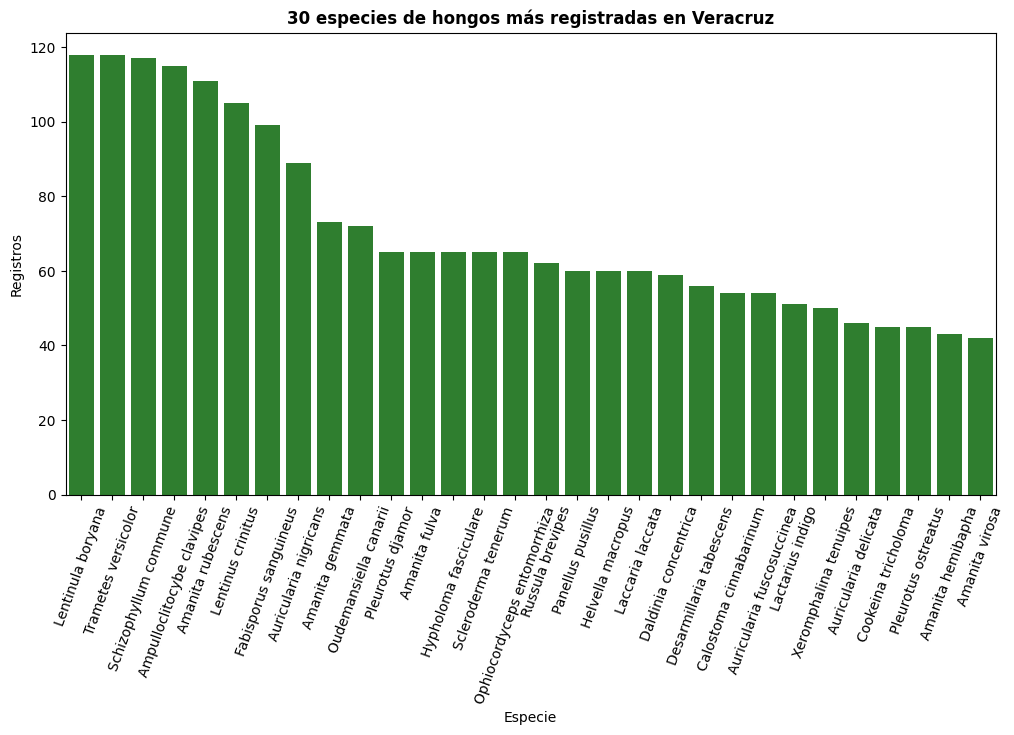

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Tabla de frecuencias de especies de hongos
tabla_especies = df['species'].value_counts().reset_index()
tabla_especies.columns = ["Especie", "Registros"]

print("Tabla de frecuencias de especies (30):")
print(tabla_especies.head(30))

# Gráfica de frecuencias de especies de hongos
plt.figure(figsize=(12,6))
sns.barplot(data=tabla_especies.head(30), x="Especie", y="Registros", color="forestgreen")
plt.title("30 especies de hongos más registradas en Veracruz", fontsize=12, fontweight="bold")
plt.xticks(rotation=70)
plt.show()

## Distribución por localidad
* ¿Cuál es la distribución de registros por regiones de Veracruz?


Tabla de frecuencias por localidad (30):
                                            Localidad  Registros
0   Jardín Botánico Francisco Javier Clavijero, km...        874
1   Los Gallos, 1.5 km al N del Ejido Ingenio El R...        535
2   El Revolcadero, 1 km al SE de Tembladeras, Eji...        453
3   Planta Piloto Productora de Hongos Comestibles...        174
4                Cerro La Martinica, SO de Banderilla        165
5   Estación Biológica de Los Tuxtlas, UNAM, cerca...        145
6   Xalapa, jardines, calles, parques, bosques y o...        130
7   Granja Santa Bárbara, carretera Xalapa-Perote,...        110
8       Zoncuantla, carretera antigua Xalapa-Coatepec        110
9                Cruz Blanca, carretera Xalapa-Perote        106
10  Rancho Santa Inés, carretera antigua Xalapa-Co...        103
11      Cerca del Río Coapexpan, 2 km al SO de Xalapa         87
12  Cerca de la Casa Asistencial CONECALLI-DIF, km...         78
13       Cerca de Huatusco, carretera Huatusco-X

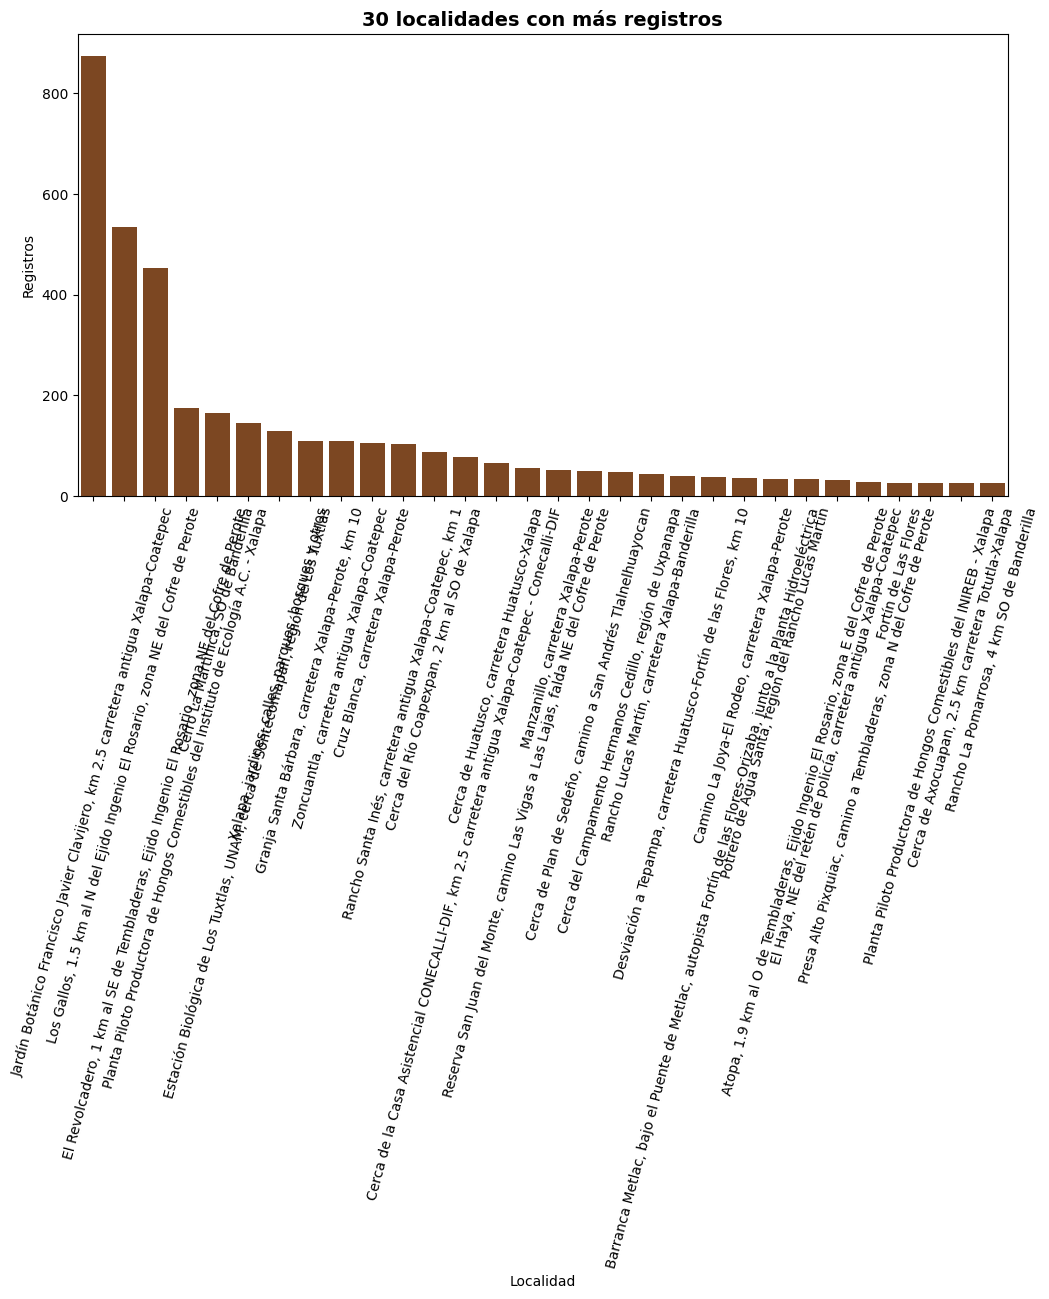

In [ ]:
tabla_localidad = df['locality'].value_counts().reset_index()
tabla_localidad.columns = ["Localidad", "Registros"]

print("\nTabla de frecuencias por localidad (30):")
print(tabla_localidad.head(30))

plt.figure(figsize=(12,6))
sns.barplot(data=tabla_localidad.head(30), x="Localidad", y="Registros", color="saddlebrown")
plt.title("30 localidades con más registros", fontsize=14, fontweight="bold")
plt.xticks(rotation=75)
plt.show()


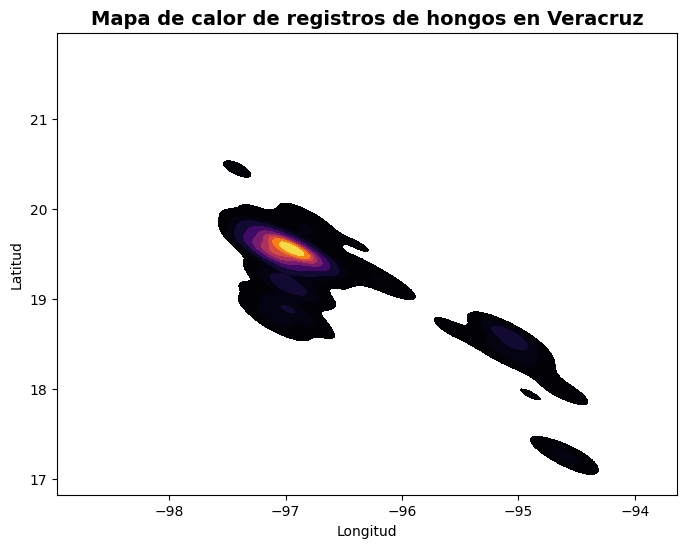

In [ ]:
# Mapa de calor de registros de hongos de Veracruz

plt.figure(figsize=(8,6))
sns.kdeplot(
    data=df.dropna(subset=["decimalLatitude","decimalLongitude"]),
    x="decimalLongitude", y="decimalLatitude",
    fill=True, cmap="inferno", thresh=0.05
)
plt.title("Mapa de calor de registros de hongos en Veracruz", fontsize=14, fontweight="bold")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.show()

##Valores atípicos
* ¿Existen valores atípicos en los registros por especie o región que puedan alterar la interpretación de la base de datos?

In [ ]:
import plotly.express as px

# Boxplot interactivo por especie
registros_especie = df['species'].value_counts().reset_index()
registros_especie.columns = ["Especie", "Registros"]

fig1 = px.box(
    registros_especie,
    y="Registros",
    points="all",
    title="Valores atípicos en registros por especie",
    color_discrete_sequence=["lightblue"]
)
fig1.update_layout(yaxis_title="Número de registros por especie")
fig1.show()

# Boxplot interactivo por localidad
registros_localidad = df['locality'].value_counts().reset_index()
registros_localidad.columns = ["Localidad", "Registros"]

fig2 = px.box(
    registros_localidad,
    y="Registros",
    points="all",
    title="Valores atípicos en registros por localidad",
    color_discrete_sequence=["lightcoral"]
)
fig2.update_layout(yaxis_title="Número de registros por localidad")
fig2.show()


In [ ]:
# Realizamos una gráfica de dispersión tridimensional de los datos latitud, longitud y elevación para conocer su distribución relacionando estas tres variables
import plotly.express as px

fig = px.scatter_3d(
    df4.dropna(subset=["decimalLatitude", "decimalLongitude", "elevation"]),
    x="decimalLongitude",
    y="decimalLatitude",
    z="elevation",
    color="family",
    size_max=4,
    opacity=0.6,
    title="Distribución tridimensional de los registros de hongos (latitud, longitud, altitud)"
)
fig.update_layout(scene=dict(
    xaxis_title='Longitud',
    yaxis_title='Latitud',
    zaxis_title='Altitud (m)'
))
fig.show()


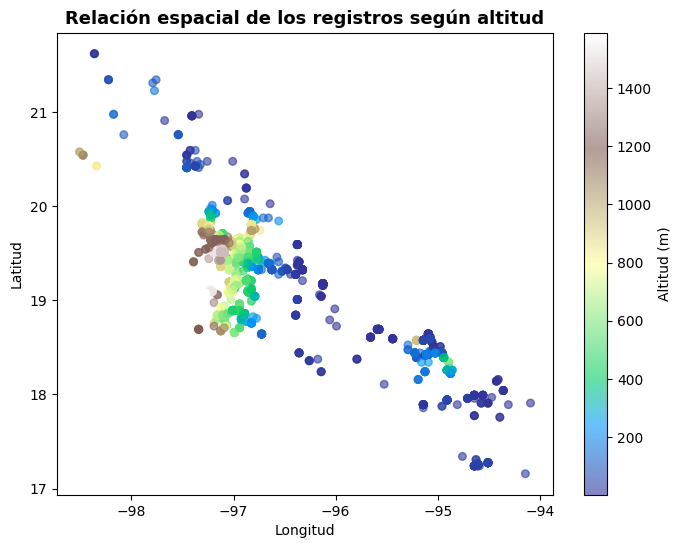

In [ ]:
# Realizamos una gráfica de dispersión en dos dimensiones para ver claramente la diferencia de altitudes

plt.figure(figsize=(8,6))
plt.scatter(
    df4["decimalLongitude"], df4["decimalLatitude"],
    c=df4["elevation"], cmap="terrain", s=30, alpha=0.6
)
plt.colorbar(label="Altitud (m)")
plt.title("Relación espacial de los registros según altitud", fontsize=13, fontweight="bold")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.show()


In [ ]:
print(df4["elevation"].describe())


count    6149.000000
mean      768.921369
std       436.739112
min         0.000000
25%       625.000000
50%       655.000000
75%      1150.000000
max      1590.000000
Name: elevation, dtype: float64


##**Métricas de calidad de los datos**

Identificar y reportar indicadores de calidad, sólo las que apliquen, tales como:

* **Completitud:** conteo y porcentaje de valores faltantes.
Se quitaron las columnas con valores nulos

* **Consistencia:** tipos de datos correctos, formatos esperados.
Se conocieron los tipos de datos usados y se cambiaron los datos de fecha en el caso que se necesitaba.

* **Unicidad:** duplicados.
Se eliminaron las columnas que tenían solo un valor, los datos no se perdieron, pero al ser duplicados para todos los valores se guardaron en un diccionario

## Conclusiones parciales
* La base de datos de hongos de Veracruz tiene una estructura que permite su limpieza, depuración y ordenamiento, para lo que se han eliminado las columnas con valores nulos o repetitivos sin perder información relevante
* Se obtuvo una clasificación taxonómica y geográfica de los registros: se obtuvieron las especies más frecuentes y las zonas con mayor recolecciones.
* El análisis espacial a través de la latitud, longitud y altitud nos permite observar que los registros se concentran en altitudes entre los 1000 y los 1700 m.s.n.m. Apartir de esta observación se pueden agregar variables de condiciones ambientales como humedad relativa y temperatura.
* La gráfica de calor confirma que existen áreas con mayor recolección, lo que puede deberse a la distribución real de las especies o la actividad de los recolectores en ciertas regiones (predilección, conocimiento previo o accesibilidad)
* Se prevée la posibilidad de construcción de un modelo predictivo de distribución de especies (SDM) que puede ayudar a calcular la probabilidad de presencia de hongos en otras zonas del estado dependiendo de características como altitud, latitud y longitud.

# **5. Análisis Exploratorio de los Datos**

## - Preguntas a responder
## - Estadísticas Empleadas, visualización y Resumen de las respuestas encontradas.

# **Preguntas a responder**
1. ¿Cuál es la diversidad de los hongos registrados en Veracruz?
2. ¿Cómo se distribuyen los registros de hongos dentro del estado por localidad, latitud, longitud y altitud?
3. ¿Existen valores atípicos o significativos por especie o localidad?
4. ¿Qué patrones se observan en relación con la altitud y la densidad de registros?

# **Estadísticas empleadas**
* Valores únicos
* Tabla de frecuencias
* Valores nulos
* Media, máximo, mínimo, desviación estándar
* Valores atípicos
* Visualizaciones espaciales: latitud, longitud, altitud, localidad

# Conclusiones parciales (2)
*  De 159 familias y 838 especies las más frecuentes son Letinula boryana, Tramestes versicolor y Schizophyllum commune.
* Se observa que la mayor concentración de registros se llevó a cabo en Xalapa, Coatepec, Banderilla y los Tuxtlas. Esto se puede deber a la actividad de los recolectores o a las condiciones ambientales adecuadas.
  * El mapa de calor nos muestra los patrones de densidad más fuertes
  * La altitud y distribución marca una mayor recolección de registros entre 1000 y 1800 m.s.n.m.
* Existen poco valores atípicos de algunas especies y localidades

## Observamos un resumen de los datos más relevantes:

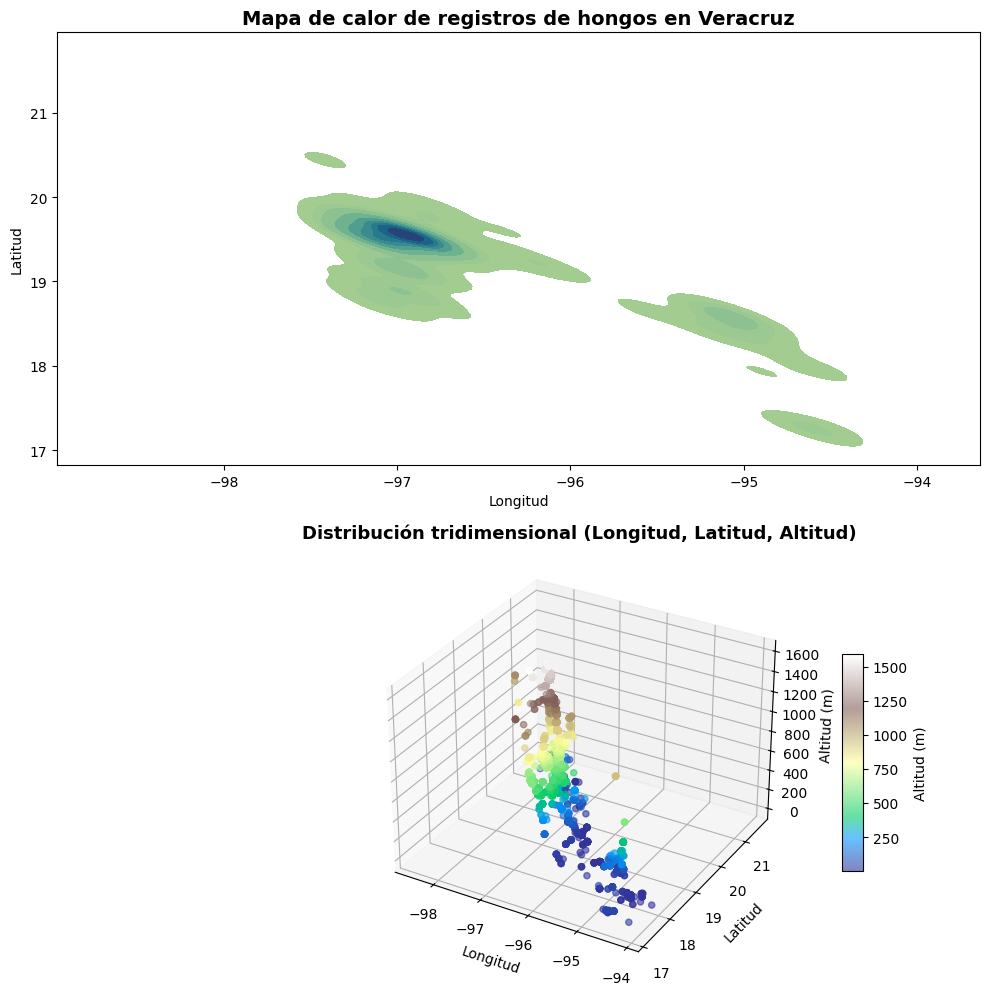

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

# Creamos figura con 2 filas
fig = plt.figure(figsize=(10, 10))

# Mapa de calor de registros de hongos de Veracruz

ax1 = fig.add_subplot(2, 1, 1)
sns.kdeplot(
    data=df4.dropna(subset=["decimalLatitude", "decimalLongitude"]),
    x="decimalLongitude",
    y="decimalLatitude",
    fill=True,
    cmap="crest",
    thresh=0.05,
    ax=ax1
)
ax1.set_title("Mapa de calor de registros de hongos en Veracruz", fontsize=14, fontweight="bold")
ax1.set_xlabel("Longitud")
ax1.set_ylabel("Latitud")


# Gráfica de dispersión tridimensional de los datos latitud, longitud y elevación
ax2 = fig.add_subplot(2, 1, 2, projection='3d')
subset = df4.dropna(subset=["decimalLatitude", "decimalLongitude", "elevation"])

p = ax2.scatter(
    subset["decimalLongitude"],
    subset["decimalLatitude"],
    subset["elevation"],
    c=subset["elevation"],
    cmap="terrain",
    s=20,
    alpha=0.6
)

ax2.set_title("Distribución tridimensional (Longitud, Latitud, Altitud)", fontsize=13, fontweight="bold")
ax2.set_xlabel("Longitud")
ax2.set_ylabel("Latitud")
ax2.set_zlabel("Altitud (m)")

fig.colorbar(p, ax=ax2, shrink=0.5, aspect=10, label="Altitud (m)")

plt.tight_layout()
plt.show()


# **6. Análisis Predictivo**

## - Preprocesamiento para Análisis Predictivo: Problemas, Técnicas y Código

## - Modelado Predictivo
### - Modelo elegido y parámetros
### - Entrenamiento y Evaluación
## - Resultados


# **7. Conclusiones y Trabajos Futuros**

## - Resumen del trabajo realizado, hallazgos y posibles mejoras